# Cas de tests du prof — Modele Lineaire & MLP

Ce notebook reprend **les 11 cas de tests fournis par le prof** (`[Notebook] Cas de tests.ipynb`),
avec **ses donnees VERBATIM**, et verifie que nos modeles reproduisent **ses annotations OK / KO**.

**Perimetre** : les annotations du prof portent sur `Linear Model` et `MLP`.
On y ajoute le **RBF** : c'est lui aussi un modele **lineaire**, mais dans l'espace transforme
par les gaussiennes — il montre donc une **3e facon** de depasser la limite lineaire
(le MLP le fait par ses couches cachees, le RBF par la transformation des entrees).
*(Le SVM, qu'aucune annotation ne mentionne, est etudie dans `experimentation_models.ipynb`.)*

| Modele | Auteur | Classification | Regression |
|---|---|---|---|
| **Lineaire** (perceptron) | Valentin | `train` (regle du perceptron) | `train_regression` (regle de Widrow-Hoff) |
| **MLP / PMC** | Thinina | `is_classification=True` (sortie tanh) | `is_classification=False` (sortie lineaire) |
| **RBF** | Ali | cibles +/-1 puis signe | regression **native** (moindres carres) |

> La colonne **Conforme** du recapitulatif ne juge que le **lineaire** et le **MLP** :
> ce sont les seuls que le prof annote. Le RBF est affiche a titre de **comparaison**.

Sur les cas **multi-classes**, le modele lineaire etant **binaire**, il est utilise en
**un-contre-tous** (1 modele par classe + argmax) : c'est le **"Linear Model x3"** du cours.
Le MLP, lui, est **nativement multi-classe** (3 neurones de sortie).

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "python"))   # rendre bindings.py trouvable

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D                          # noqa: F401  (affichage 3D)
from bindings import MLP, ModeleLineaire, RBFNetwork, UnContreTous

np.random.seed(0)                                       # resultats reproductibles
PALETTE = np.array(["#1f77b4", "#d62728", "#2ca02c"])   # bleu / rouge / vert


def _classe(scores):
    """Liste de scores -> numero de classe.
    1 score  -> binaire : le signe   (>=0 -> classe 1, sinon classe 0)
    3 scores -> multi   : l'argmax"""
    return int(scores[0] >= 0) if len(scores) == 1 else int(np.argmax(scores))


# Le MLP est non convexe : selon l'initialisation, la descente de gradient peut se
# coincer dans un minimum local. Avec l'architecture minimale [2,2,1] sur les cas
# type XOR, on mesure une MSE entre 0.00 et 1.13 selon le tirage. On garde donc
# l'architecture et on reinitialise jusqu'a `essais` fois.

def mlp_robuste_classif(X, Yc, arch, steps, lr, activation, cls_vraie, essais=1, seuil=100.0):
    """Entraine le MLP ; re-initialise s'il se coince. Garde le meilleur essai."""
    best, best_acc = None, -1.0
    for _ in range(max(1, essais)):
        m = MLP(arch, activation=activation)
        m.fit(X, Yc, steps=steps, lr=lr, is_classification=True)
        acc = 100.0 * np.mean([_classe(m.predict(list(x))) for x in X] == cls_vraie)
        if acc > best_acc:
            best, best_acc = m, acc
        if acc >= seuil:
            break
    return best


def mlp_robuste_reg(X, Y, arch, steps, lr, essais=1, seuil=1e-3):
    """Idem pour la REGRESSION : on garde l'essai de plus faible MSE."""
    best, best_mse = None, float("inf")
    for _ in range(max(1, essais)):
        m = MLP(arch)
        m.fit(X, Y.reshape(-1, 1), steps=steps, lr=lr, is_classification=False)
        pred = np.array([m.predict(list(x), is_classification=False)[0] for x in X])
        mse = float(np.mean((pred - Y.ravel()) ** 2))
        if mse < best_mse:
            best, best_mse = m, mse
        if mse <= seuil:
            break
    return best


def entraine(X, Y, p):
    """Entraine le MLP et le Lineaire sur un cas de CLASSIFICATION.
    Y : (n,) en +/-1 [binaire]  OU  (n,3) one-hot +/-1 [multi-classe].
    Renvoie [(nom, f)] ou f(x) donne la liste des scores."""
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    binaire = (Y.ndim == 1) or (Y.shape[1] == 1)
    Yc = Y.reshape(-1, 1) if binaire else Y
    cls_vraie = (Yc[:, 0] >= 0).astype(int) if binaire else np.argmax(Yc, axis=1)
    Xl = X.tolist()
    out = []

    # ---- MLP (Thinina) : binaire ET multi-classe nativement
    arch = p["mlp"]["arch"]
    m = mlp_robuste_classif(X, Yc, arch, p["mlp"]["steps"], p["mlp"]["lr"],
                            p["mlp"].get("activation", "tanh"), cls_vraie,
                            essais=p["mlp"].get("essais", 1),
                            seuil=p["mlp"].get("seuil", 100.0))
    out.append((f"MLP {arch}", lambda x, m=m: m.predict(list(x))))

    # ---- Lineaire (Valentin) : binaire -> un-contre-tous si 3 classes
    if binaire:
        l = ModeleLineaire(X.shape[1])
        l.fit(Xl, Yc[:, 0].tolist(), lr=p["lin"]["lr"], epochs=p["lin"]["epochs"])
        out.append(("Lineaire", lambda x, l=l: [l.predict_value(list(x))]))
    else:
        yl = np.argmax(Yc, axis=1).tolist()
        u = UnContreTous.entrainer(ModeleLineaire, Xl, yl, Yc.shape[1],
                                   lr=p["lin"]["lr"], epochs=p["lin"]["epochs"])
        out.append(("Lineaire x3", lambda x, u=u: u.predict(list(x))))

    # ---- RBF (Ali) : c'est un modele LINEAIRE, mais dans l'espace des gaussiennes.
    # D'ou son interet ici : il montre une 3e facon de depasser la limite lineaire
    # (le MLP le fait par les couches cachees, le RBF par la transformation des entrees).
    k, g, it = p["rbf"]["k"], p["rbf"]["gamma"], p["rbf"]["iters"]
    if binaire:
        r = RBFNetwork(k=k, gamma=g)
        r.train(Xl, Yc[:, 0].tolist(), k=k, iterations=it)
        out.append((f"RBF (k={k})", lambda x, r=r: [r.predict(list(x))]))
    else:
        y_idx = np.argmax(Yc, axis=1)
        rs = []
        for c in range(Yc.shape[1]):                      # un-contre-tous : 1 reseau par classe
            r = RBFNetwork(k=k, gamma=g)
            r.train(Xl, np.where(y_idx == c, 1.0, -1.0).tolist(), k=k, iterations=it)
            rs.append(r)
        out.append((f"RBF x3 (k={k})", lambda x, rs=rs: [r.predict(list(x)) for r in rs]))
    return out


def _frontiere(ax, f, X, cls_vraie, res=60):
    """Dessine la frontiere de decision (fond colore) + les points reels."""
    a0, b0 = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    a1, b1 = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    gx, gy = np.meshgrid(np.linspace(a0, b0, res), np.linspace(a1, b1, res))
    cls = np.array([_classe(f([a, b])) for a, b in zip(gx.ravel(), gy.ravel())])
    ax.scatter(gx.ravel(), gy.ravel(), c=PALETTE[cls], s=6, alpha=0.22)
    ax.scatter(X[:, 0], X[:, 1], c=PALETTE[cls_vraie], edgecolor="k", s=28)


RECAP = {}   # {cas: {modele: score}}  -> alimente le tableau final


def montre_classif(X, Y, p, titre, attendu):
    """Verite terrain + frontiere de decision de chaque modele + precision."""
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    binaire = (Y.ndim == 1) or (Y.shape[1] == 1)
    Yc = Y.reshape(-1, 1) if binaire else Y
    cls_vraie = (Yc[:, 0] >= 0).astype(int) if binaire else np.argmax(Yc, axis=1)

    modeles = entraine(X, Y, p)
    fig, ax = plt.subplots(1, len(modeles) + 1, figsize=(4.2 * (len(modeles) + 1), 4.0))
    ax[0].scatter(X[:, 0], X[:, 1], c=PALETTE[cls_vraie], edgecolor="k", s=28)
    ax[0].set_title("Verite terrain")

    res = {}
    for k, (nom, f) in enumerate(modeles):
        acc = 100.0 * np.mean(np.array([_classe(f(x)) for x in X]) == cls_vraie)
        res[nom] = acc
        _frontiere(ax[k + 1], f, X, cls_vraie)
        ax[k + 1].set_title(f"{nom}\n{acc:.0f}%")
    fig.suptitle(f"{titre}      |      attendu par le prof : {attendu}", fontsize=11)
    plt.tight_layout(); plt.show()

    print(f"{titre}  --  attendu par le prof : {attendu}")
    for nom, acc in res.items():
        print(f"  {nom:16s} : {acc:5.1f}% de bonnes classifications")
    RECAP[titre] = res


def montre_reg(X, Y, p, titre, attendu):
    """Cas de REGRESSION : MLP + Lineaire (via fit_regression)."""
    X = np.asarray(X, float); Y = np.asarray(Y, float).ravel()

    m = mlp_robuste_reg(X, Y, p["mlp"]["arch"], p["mlp"]["steps"], p["mlp"]["lr"],
                        essais=p["mlp"].get("essais", 1), seuil=p["mlp"].get("seuil", 1e-3))
    l = ModeleLineaire(X.shape[1])
    l.fit_regression(X.tolist(), Y.tolist(), lr=p["lin"]["lr"], epochs=p["lin"]["epochs"])
    r = RBFNetwork(k=p["rbf"]["k"], gamma=p["rbf"]["gamma"])
    r.train(X.tolist(), Y.tolist(), k=p["rbf"]["k"], iterations=p["rbf"]["iters"])
    modeles = [(f"MLP {p['mlp']['arch']}", lambda x, m=m: m.predict(list(x), is_classification=False)[0]),
               ("Lineaire", lambda x, l=l: l.predict_value(list(x))),
               (f"RBF (k={p['rbf']['k']})", lambda x, r=r: r.predict(list(x)))]

    res = {}
    if X.shape[1] == 1:
        # 1 entree -> on trace la COURBE apprise (2 axes).
        # /!\ Quand les 2 modeles trouvent la meme solution, leurs courbes se
        # superposent au pixel pres -> styles et epaisseurs DIFFERENTS.
        xs = np.linspace(X[:, 0].min() - 0.2, X[:, 0].max() + 0.2, 120)
        styles = [("-", 4.5), ("--", 2.5), (":", 2.0)]
        plt.figure(figsize=(7.5, 4.4))
        for k, (nom, f) in enumerate(modeles):
            mse = float(np.mean([(f(x) - y) ** 2 for x, y in zip(X, Y)]))
            res[nom] = mse
            ls, lw = styles[k % len(styles)]
            plt.plot(xs, [f([x]) for x in xs], ls, lw=lw, label=f"{nom}  (MSE={mse:.4f})")
        plt.scatter(X[:, 0], Y, color="black", s=90, zorder=10, label="donnees reelles")
        plt.legend(); plt.grid(alpha=0.3)
        plt.title(f"{titre}   |   attendu par le prof : {attendu}")
    else:
        # 2 entrees -> UNE SURFACE PAR MODELE, cote a cote.
        # Afficher juste les points predits ne marche pas : quand un modele reussit
        # (MSE=0) ses points sont SOUS les points reels et deviennent invisibles.
        # La SURFACE APPRISE, elle, montre ce que le modele SAIT faire :
        #   - le lineaire ne peut produire qu'un PLAN -> son echec devient visible
        #   - le MLP courbe sa surface pour toucher les points -> sa reussite est visible
        a0, b0 = X[:, 0].min() - 0.25, X[:, 0].max() + 0.25
        a1, b1 = X[:, 1].min() - 0.25, X[:, 1].max() + 0.25
        gx, gy = np.meshgrid(np.linspace(a0, b0, 30), np.linspace(a1, b1, 30))

        fig = plt.figure(figsize=(5.4 * len(modeles), 4.8))
        for k, (nom, f) in enumerate(modeles):
            pred = np.array([f(x) for x in X])
            mse = float(np.mean((pred - Y) ** 2))
            res[nom] = mse
            gz = np.array([f([u, v]) for u, v in zip(gx.ravel(), gy.ravel())]).reshape(gx.shape)
            a = fig.add_subplot(1, len(modeles), k + 1, projection="3d")
            a.plot_surface(gx, gy, gz, alpha=0.45, cmap="viridis")       # la surface apprise
            a.scatter(X[:, 0], X[:, 1], Y, color="black", s=70,
                      depthshade=False, label="donnees reelles")         # les vrais points
            for xi, yi, pi in zip(X, Y, pred):                           # l'ecart reel <-> predit
                a.plot([xi[0], xi[0]], [xi[1], xi[1]], [yi, pi], color="red", lw=2.5)
            a.set_title(f"{nom}\nMSE = {mse:.4f}", fontsize=10)
            a.set_xlabel("entree 1", fontsize=8); a.set_ylabel("entree 2", fontsize=8)
            a.set_zlabel("sortie", fontsize=8)
        fig.suptitle(f"{titre}   |   attendu par le prof : {attendu}"
                     f"     (points noirs = realite, traits rouges = erreur)", fontsize=11)
    plt.tight_layout(); plt.show()

    print(f"{titre}  --  attendu par le prof : {attendu}")
    for nom, v in res.items():
        print(f"  {nom:16s} : MSE = {v:.4f}")
    RECAP[titre] = res

## Classification — 6 cas

Pour chaque cas : la **verite terrain**, puis la **frontiere de decision** apprise par chaque modele.
Le titre rappelle **l'annotation du prof** pour comparer directement.

### 1. Linear Simple
Prof : `Linear Model : OK`  —  `MLP (2, 1) : OK`

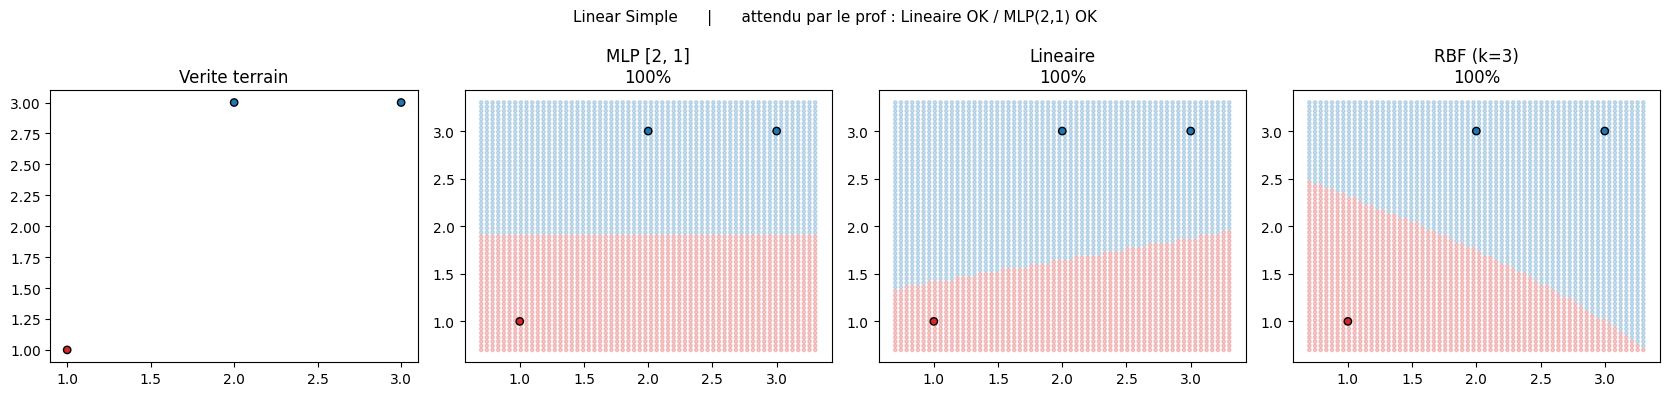

Linear Simple  --  attendu par le prof : Lineaire OK / MLP(2,1) OK
  MLP [2, 1]       : 100.0% de bonnes classifications
  Lineaire         : 100.0% de bonnes classifications
  RBF (k=3)        : 100.0% de bonnes classifications


In [2]:
# Donnees VERBATIM du notebook du prof
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

P = {"mlp": {"arch": [2, 1], "steps": 50_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 200},
     "rbf": {"k": 3, "gamma": 1.0, "iters": 20}}      # k = nb de points -> interpolation exacte

montre_classif(X, Y, P, "Linear Simple", "Lineaire OK / MLP(2,1) OK")

### 2. Linear Multiple
Prof : `Linear Model : OK`  —  `MLP (2, 1) : OK`

100 points en **deux nuages** separes par un espace vide -> toujours lineairement separable.

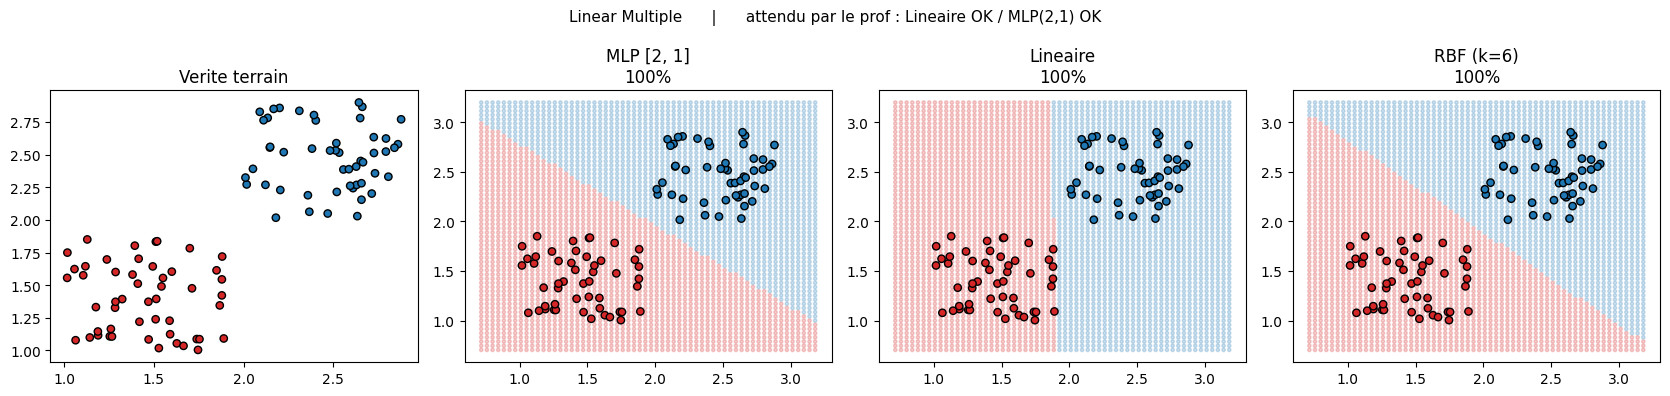

Linear Multiple  --  attendu par le prof : Lineaire OK / MLP(2,1) OK
  MLP [2, 1]       : 100.0% de bonnes classifications
  Lineaire         : 100.0% de bonnes classifications
  RBF (k=6)        : 100.0% de bonnes classifications


In [3]:
# Donnees VERBATIM du notebook du prof
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

P = {"mlp": {"arch": [2, 1], "steps": 50_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 100},
     "rbf": {"k": 6, "gamma": 1.0, "iters": 20}}      # 2 nuages simples -> peu de centres

montre_classif(X, Y, P, "Linear Multiple", "Lineaire OK / MLP(2,1) OK")

### 3. XOR
Prof : `Linear Model : KO`  —  `MLP (2, 2, 1) : OK`

**Le cas historique** (Minsky & Papert, 1969) : XOR n'est **pas lineairement separable**.
Le perceptron ne trace qu'**une droite** -> il echoue forcement. Il faut une **couche cachee**.

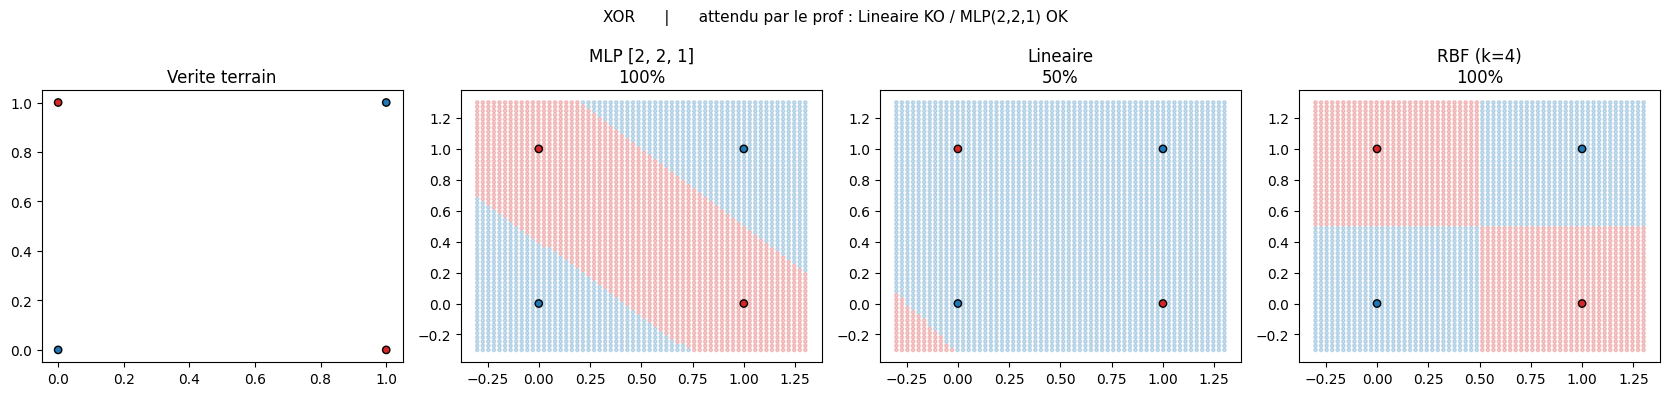

XOR  --  attendu par le prof : Lineaire KO / MLP(2,2,1) OK
  MLP [2, 2, 1]    : 100.0% de bonnes classifications
  Lineaire         :  50.0% de bonnes classifications
  RBF (k=4)        : 100.0% de bonnes classifications


In [4]:
# Donnees VERBATIM du notebook du prof
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

P = {"mlp": {"arch": [2, 2, 1], "steps": 300_000, "lr": 0.01, "essais": 5, "seuil": 100.0},
     "lin": {"lr": 0.01, "epochs": 200},
     "rbf": {"k": 4, "gamma": 1.0, "iters": 20}}      # 1 centre par point du XOR

montre_classif(X, Y, P, "XOR", "Lineaire KO / MLP(2,2,1) OK")

### 4. Cross
Prof : `Linear Model : KO`  —  `MLP (2, 4, 1) : OK`

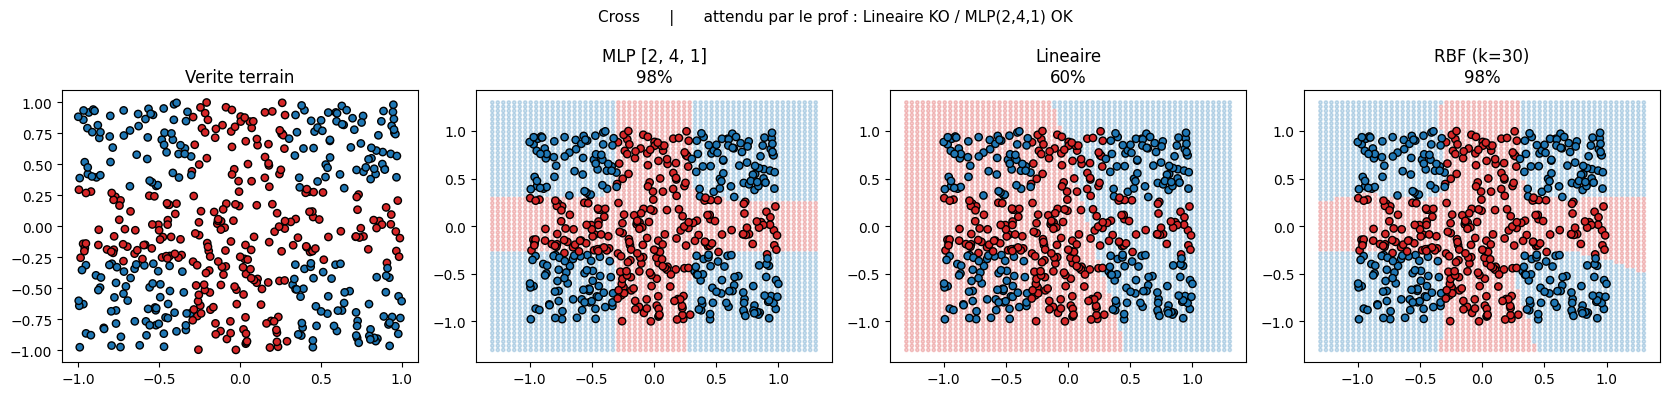

Cross  --  attendu par le prof : Lineaire KO / MLP(2,4,1) OK
  MLP [2, 4, 1]    :  98.0% de bonnes classifications
  Lineaire         :  59.6% de bonnes classifications
  RBF (k=30)       :  97.8% de bonnes classifications


In [5]:
# Donnees VERBATIM du notebook du prof
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

P = {"mlp": {"arch": [2, 4, 1], "steps": 300_000, "lr": 0.01, "essais": 3, "seuil": 98.0},
     "lin": {"lr": 0.01, "epochs": 100},
     "rbf": {"k": 30, "gamma": 5.0, "iters": 20}}     # motif en croix -> plus de centres

montre_classif(X, Y, P, "Cross", "Lineaire KO / MLP(2,4,1) OK")

### 5. Multi Linear 3 classes
Prof : `Linear Model x3 : OK`  —  `MLP (2, 3) : OK`

3 classes separees par des **droites**. Le MLP a **3 sorties** (natif) ; le lineaire, binaire,
est utilise en **un-contre-tous** -> c'est le **"Linear Model x3"**.

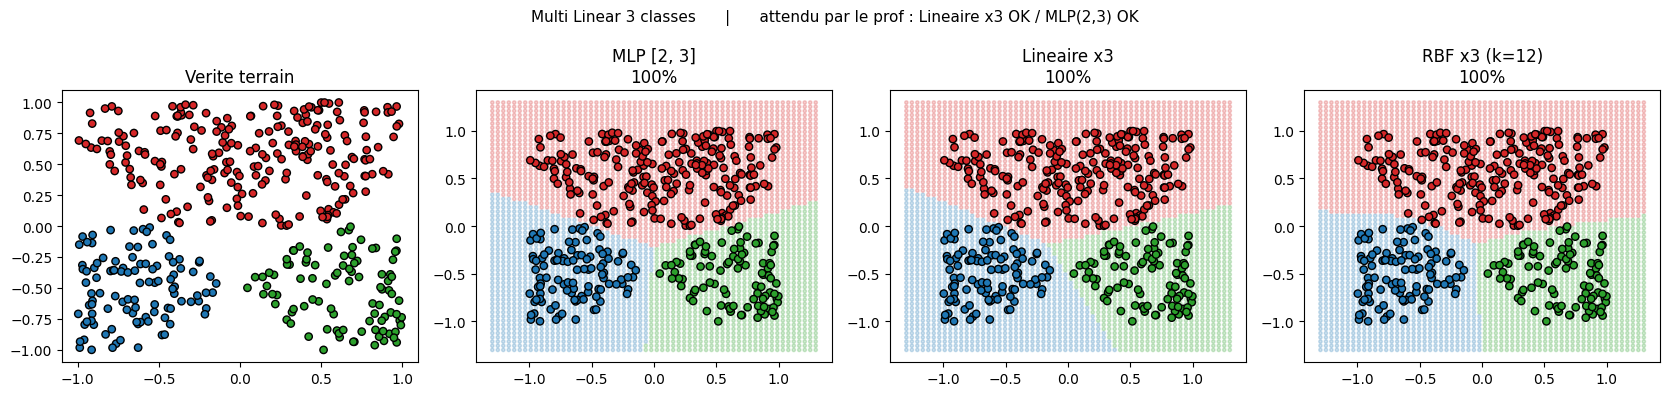

Multi Linear 3 classes  --  attendu par le prof : Lineaire x3 OK / MLP(2,3) OK
  MLP [2, 3]       : 100.0% de bonnes classifications
  Lineaire x3      : 100.0% de bonnes classifications
  RBF x3 (k=12)    : 100.0% de bonnes classifications


In [6]:
# Donnees VERBATIM du notebook du prof
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

P = {"mlp": {"arch": [2, 3], "steps": 100_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 100},
     "rbf": {"k": 12, "gamma": 2.0, "iters": 20}}     # 3 regions delimitees par des droites

montre_classif(X, Y, P, "Multi Linear 3 classes", "Lineaire x3 OK / MLP(2,3) OK")

### 6. Multi Cross
Prof : `Linear Model x3 : KO`  —  `MLP (2, ?, ?, 3) : OK`  <- **le plus dur**

**La demonstration de la limite du lineaire** : multiplier les modeles lineaires ne cree
**pas** de non-linearite. 3 droites restent 3 droites.

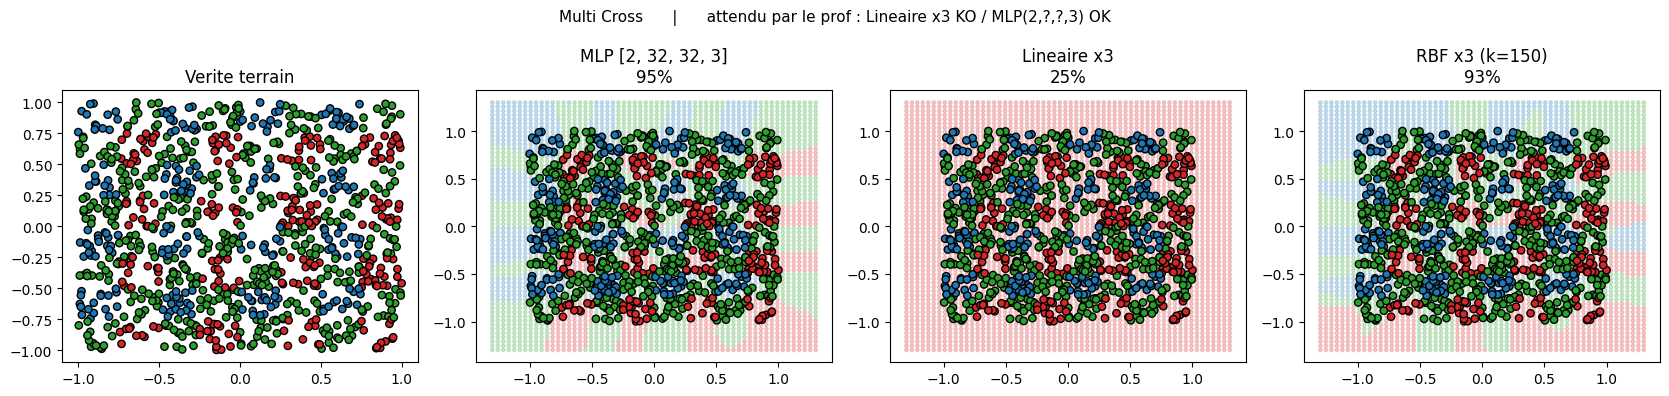

Multi Cross  --  attendu par le prof : Lineaire x3 KO / MLP(2,?,?,3) OK
  MLP [2, 32, 32, 3] :  95.1% de bonnes classifications
  Lineaire x3      :  24.8% de bonnes classifications
  RBF x3 (k=150)   :  93.1% de bonnes classifications


In [7]:
# Donnees VERBATIM du notebook du prof
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

P = {"mlp": {"arch": [2, 32, 32, 3], "steps": 800_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 100},
     "rbf": {"k": 150, "gamma": 50.0, "iters": 25}}   # grille tres fine -> beaucoup de centres
                                                      # + forte localite (mesure : 92.2%)

montre_classif(X, Y, P, "Multi Cross", "Lineaire x3 KO / MLP(2,?,?,3) OK")

## Regression — 5 cas

La sortie n'est plus une classe mais une **valeur continue** :
- **MLP** : derniere couche **lineaire** (`is_classification=False`)
- **Lineaire** : `fit_regression` — regle de **Widrow-Hoff**

> **La difference entre les deux entrainements du lineaire tient en UNE ligne** :
> le perceptron apprend sur le **SIGNE** (`predict_class`), la regression sur la
> **VALEUR CONTINUE** (`predict_value`). Le reste (descente de gradient) est identique.

On mesure la **MSE** (erreur quadratique moyenne) : **0 = parfait**.

Les graphes montrent la **surface/courbe apprise** + les points reels, et un **trait rouge**
pour l'erreur de chaque point.

### 7. Linear Simple 2D
Prof : `Linear Model : OK`  —  `MLP (1, 1) : OK`

> Les deux courbes se **superposent** : un MLP `[1,1]` sans couche cachee et a sortie lineaire
> calcule `b + w*x` — c'est **exactement** un modele lineaire. Le PMC contient le modele
> lineaire comme **cas particulier**.

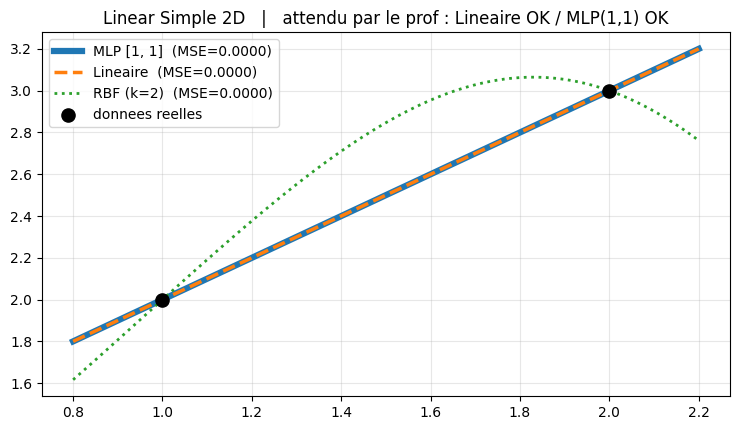

Linear Simple 2D  --  attendu par le prof : Lineaire OK / MLP(1,1) OK
  MLP [1, 1]       : MSE = 0.0000
  Lineaire         : MSE = 0.0000
  RBF (k=2)        : MSE = 0.0000


In [8]:
# Donnees VERBATIM du notebook du prof
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

P = {"mlp": {"arch": [1, 1], "steps": 50_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 20_000},
     "rbf": {"k": 2, "gamma": 1.0, "iters": 20}}

montre_reg(X, Y, P, "Linear Simple 2D", "Lineaire OK / MLP(1,1) OK")

### 8. Non Linear Simple 2D
Prof : `Linear Model : OK`  —  `MLP (1, ?, 1) : OK`

Les 3 points ne sont pas alignes : aucune droite ne peut passer par les 3.
La meilleure droite au sens des moindres carres est `y = 2 + 0.25x`, d'erreur minimale
theorique **0.125**. Le `Linear Model : OK` signifie donc "converge vers la meilleure
solution lineaire", et non "MSE = 0".

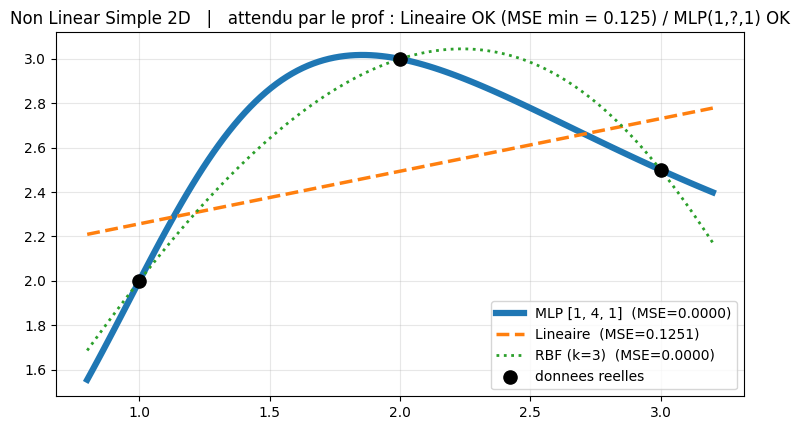

Non Linear Simple 2D  --  attendu par le prof : Lineaire OK (MSE min = 0.125) / MLP(1,?,1) OK
  MLP [1, 4, 1]    : MSE = 0.0000
  Lineaire         : MSE = 0.1251
  RBF (k=3)        : MSE = 0.0000


In [9]:
# Donnees VERBATIM du notebook du prof
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

P = {"mlp": {"arch": [1, 4, 1], "steps": 100_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 20_000},
     "rbf": {"k": 3, "gamma": 1.0, "iters": 20}}

montre_reg(X, Y, P, "Non Linear Simple 2D", "Lineaire OK (MSE min = 0.125) / MLP(1,?,1) OK")

### 9. Linear Simple 3D
Prof : `Linear Model : OK`  —  `MLP (2, 1) : OK`

> "3D" = **2 entrees + 1 sortie** -> il faut 3 axes pour visualiser.

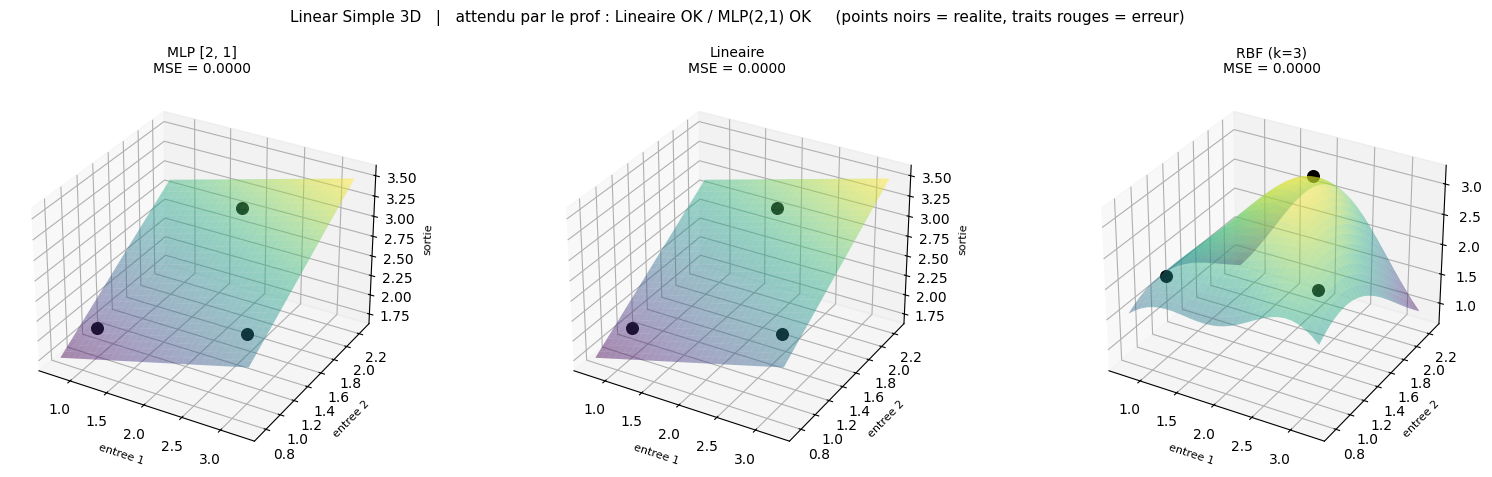

Linear Simple 3D  --  attendu par le prof : Lineaire OK / MLP(2,1) OK
  MLP [2, 1]       : MSE = 0.0000
  Lineaire         : MSE = 0.0000
  RBF (k=3)        : MSE = 0.0000


In [10]:
# Donnees VERBATIM du notebook du prof
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

P = {"mlp": {"arch": [2, 1], "steps": 50_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 20_000},
     "rbf": {"k": 3, "gamma": 1.0, "iters": 20}}

montre_reg(X, Y, P, "Linear Simple 3D", "Lineaire OK / MLP(2,1) OK")

### 10. Linear Tricky 3D
Prof : `Linear Model : OK`  —  `MLP (2, 1) : OK`

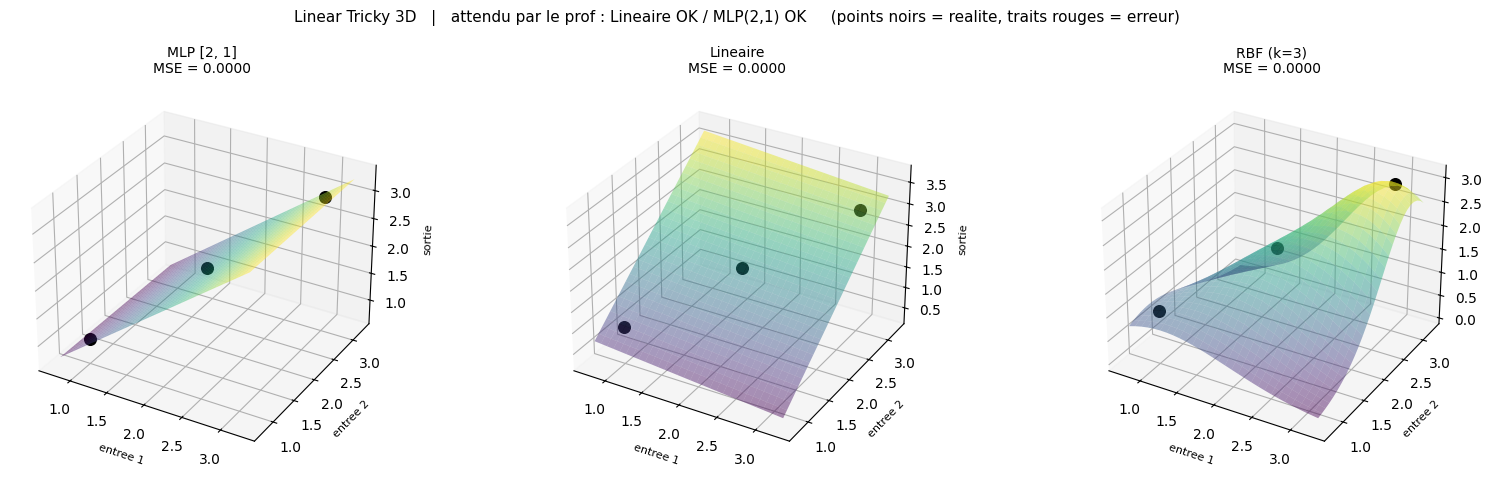

Linear Tricky 3D  --  attendu par le prof : Lineaire OK / MLP(2,1) OK
  MLP [2, 1]       : MSE = 0.0000
  Lineaire         : MSE = 0.0000
  RBF (k=3)        : MSE = 0.0000


In [11]:
# Donnees VERBATIM du notebook du prof
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

P = {"mlp": {"arch": [2, 1], "steps": 50_000, "lr": 0.01},
     "lin": {"lr": 0.01, "epochs": 20_000},
     "rbf": {"k": 3, "gamma": 1.0, "iters": 20}}

montre_reg(X, Y, P, "Linear Tricky 3D", "Lineaire OK / MLP(2,1) OK")

### 11. Non Linear Simple 3D
Prof : `Linear Model : KO`  —  `MLP (2, 2, 1) : OK`

C'est un **XOR en regression** : la sortie monte en (1,0), descend en (1,1)...
**Aucun plan** ne peut passer par les 4 points -> le lineaire **doit echouer** (le `KO` du prof),
le MLP **doit reussir** en courbant sa surface. **Comparez les deux surfaces ci-dessous.**

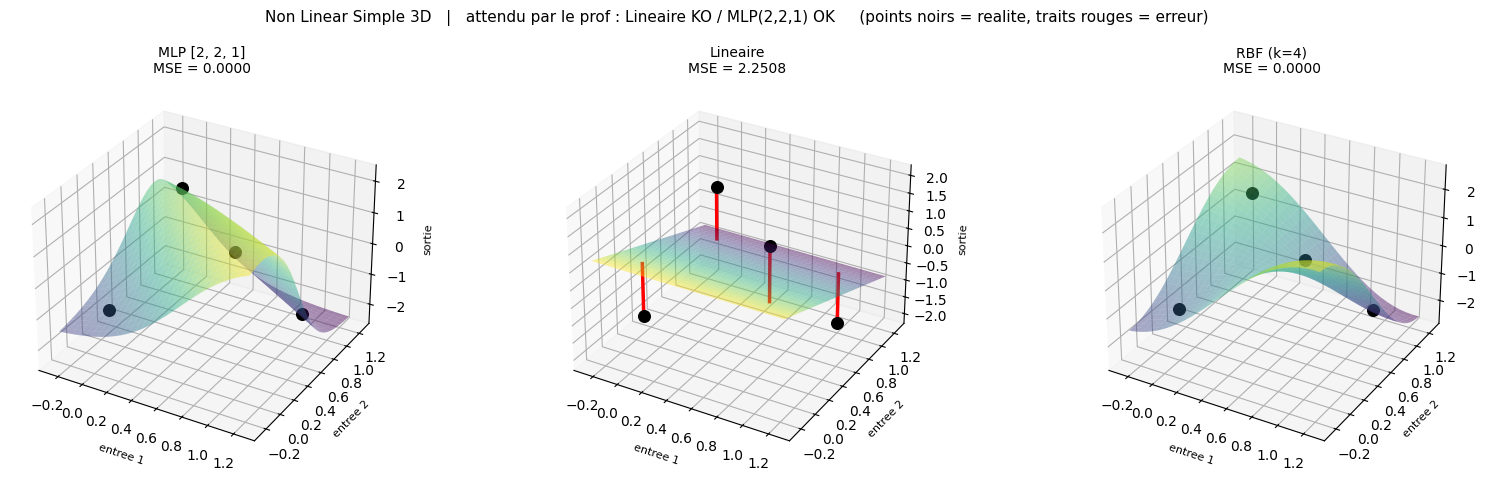

Non Linear Simple 3D  --  attendu par le prof : Lineaire KO / MLP(2,2,1) OK
  MLP [2, 2, 1]    : MSE = 0.0000
  Lineaire         : MSE = 2.2508
  RBF (k=4)        : MSE = 0.0000


In [12]:
# Donnees VERBATIM du notebook du prof
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

P = {"mlp": {"arch": [2, 2, 1], "steps": 200_000, "lr": 0.01, "essais": 6, "seuil": 1e-3},
     "lin": {"lr": 0.01, "epochs": 20_000},
     "rbf": {"k": 4, "gamma": 1.0, "iters": 20}}

montre_reg(X, Y, P, "Non Linear Simple 3D", "Lineaire KO / MLP(2,2,1) OK")

## Recapitulatif — nos resultats face aux annotations du prof

In [13]:
import pandas as pd

ATTENDU = {   # les annotations du prof, cas par cas
    "Linear Simple":          ("OK", "OK"),
    "Linear Multiple":        ("OK", "OK"),
    "XOR":                    ("KO", "OK"),
    "Cross":                  ("KO", "OK"),
    "Multi Linear 3 classes": ("OK", "OK"),
    "Multi Cross":            ("KO", "OK"),
    "Linear Simple 2D":       ("OK", "OK"),
    "Non Linear Simple 2D":   ("OK", "OK"),
    "Linear Simple 3D":       ("OK", "OK"),
    "Linear Tricky 3D":       ("OK", "OK"),
    "Non Linear Simple 3D":   ("KO", "OK"),
}
CLASSIF = ["Linear Simple", "Linear Multiple", "XOR", "Cross",
           "Multi Linear 3 classes", "Multi Cross"]

# MSE MINIMALE atteignable par une DROITE sur chaque cas de regression.
# Attention : "Non Linear Simple 2D" a 3 points NON ALIGNES -> aucune droite ne peut
# passer par les 3. La meilleure droite (moindres carres) est y = 2 + 0.25x et son
# erreur vaut exactement 0.125 : ce n'est PAS un echec, c'est l'optimum.
# Un "Linear Model : OK" chez le prof signifie donc "converge vers la meilleure
# solution lineaire", et non "MSE = 0". D'ou ce tableau au lieu d'un seuil unique.
OPTIMUM_LINEAIRE = {
    "Linear Simple 2D":     0.0,
    "Non Linear Simple 2D": 0.125,   # <- l'optimum theorique, pas zero
    "Linear Simple 3D":     0.0,
    "Linear Tricky 3D":     0.0,
    "Non Linear Simple 3D": None,    # KO attendu : aucun plan ne convient
}

lignes = []
for cas, res in RECAP.items():
    vals = {}
    for nom, v in res.items():
        cle = nom.split(" (")[0].split(" [")[0].replace(" x3", "")   # "Lineaire x3" -> "Lineaire"
        vals[cle] = v
    est_classif = cas in CLASSIF

    def verdict_mlp(v):
        # classification : reussi si >= 90%  |  regression : reussi si il interpole
        return ("OK" if v >= 90 else "KO") if est_classif else ("OK" if v < 0.05 else "KO")

    def verdict_lin(v):
        if est_classif:
            return "OK" if v >= 90 else "KO"
        opt = OPTIMUM_LINEAIRE.get(cas)
        if opt is None:                       # cas ou le lineaire DOIT echouer
            return "KO" if v > 0.05 else "OK"
        return "OK" if v <= opt + 0.01 else "KO"   # a-t-il atteint son optimum ?

    a_lin, a_mlp = ATTENDU[cas]
    v_lin, v_mlp = verdict_lin(vals["Lineaire"]), verdict_mlp(vals["MLP"])
    lignes.append({
        "Cas": cas,
        "Type": "classif" if est_classif else "regression",
        "Lineaire": f"{vals['Lineaire']:.2f}",
        "attendu (Lin.)": a_lin,
        "MLP": f"{vals['MLP']:.2f}",
        "attendu (MLP)": a_mlp,
        "RBF": f"{vals['RBF']:.2f}",     # informatif : le prof ne l'annote pas
        "Conforme": "oui" if (v_lin == a_lin and v_mlp == a_mlp) else "NON",
    })

df = pd.DataFrame(lignes).set_index("Cas")
n_ok = sum(1 for l in lignes if l["Conforme"] == "oui")
print("classif = precision en %  (100 = parfait)   |   regression = MSE  (0 = parfait)")
print("Sur les cas multi-classes, le lineaire et le RBF sont en un-contre-tous (Linear Model x3).")
print("La colonne 'Conforme' ne juge que le lineaire et le MLP : le prof n'annote pas le RBF.")
print(f"\n==> {n_ok}/{len(lignes)} cas conformes aux annotations du prof.")
df

classif = precision en %  (100 = parfait)   |   regression = MSE  (0 = parfait)
Sur les cas multi-classes, le lineaire et le RBF sont en un-contre-tous (Linear Model x3).
La colonne 'Conforme' ne juge que le lineaire et le MLP : le prof n'annote pas le RBF.

==> 11/11 cas conformes aux annotations du prof.


,Type,Lineaire,attendu (Lin.),MLP,attendu (MLP),RBF,Conforme
Cas,,,,,,,
Linear Simple,classif,100.00,OK,100.00,OK,100.00,oui
Linear Multiple,classif,100.00,OK,100.00,OK,100.00,oui
XOR,classif,50.00,KO,100.00,OK,100.00,oui
Cross,classif,59.60,KO,98.00,OK,97.80,oui
Multi Linear 3 classes,classif,100.00,OK,100.00,OK,100.00,oui
Multi Cross,classif,24.80,KO,95.10,OK,93.10,oui
Linear Simple 2D,regression,0.00,OK,0.00,OK,0.00,oui
Non Linear Simple 2D,regression,0.13,OK,0.00,OK,0.00,oui
Linear Simple 3D,regression,0.00,OK,0.00,OK,0.00,oui
